In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
training_names = ["Transformer0e_2bit","Transformer40e_2bit", "Transformer80e_2bit","Transformer120e_2bit","Transformer0e_3bit", "Transformer40e_3bit","Transformer80e_3bit","Transformer120e_3bit"]

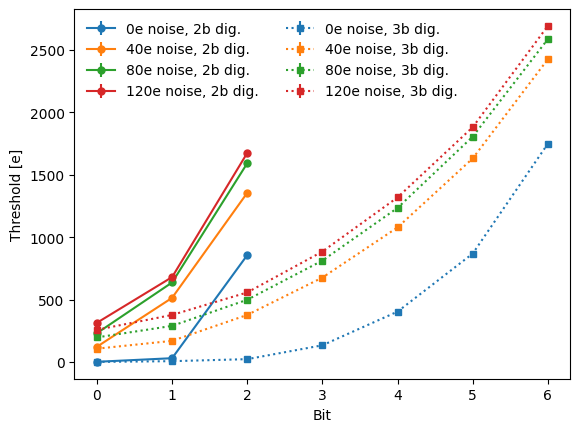

In [3]:
lines = []
for t in training_names:
    df = pd.read_parquet("avg_thr_"+t+".parquet")

    bits = [0,1,2]
    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if '3bit' in t:
        bits = [0,1,2,3,4,5,6]
        marker = 's'
        ls = ':'
    
    if '40e' in t:
        color='tab:orange'
    elif '80e' in t:
        color = 'tab:green'
    elif '120e' in t:
        color = 'tab:red'
    
    lines += plt.errorbar(x=bits, y=df['mean'], yerr=df['sigma'], linestyle=ls,marker=marker,ms=5,label=t, color=color)
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

labels = ['0e noise, 2b dig.','40e noise, 2b dig.','80e noise, 2b dig.','120e noise, 2b dig.',
          '0e noise, 3b dig.','40e noise, 3b dig.','80e noise, 3b dig.','120e noise, 3b dig.']

plt.legend(labels=labels,ncols=2,frameon=False);